# DC-QAOA Visualization Notebook
This notebook runs the DC-QAOA Max-Cut pipeline step-by-step and visualizes the problem graph, subgraph partitions, and the final optimized solution.

In [1]:
import sys
import ast
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

from pathlib import Path
from typing import Optional

import solver as _solver_module
from graph_loader import load_graph
from partitioner import recursive_partition, PartitionNode
from solver import qaoa_solve, setup_qpu, USE_PYQUIL, _local_search
from merger import merge
from scorer import maxcut_score

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 8)
plt.rcParams['figure.dpi'] = 100

## 1. Helper Functions for Visualization

In [11]:
def draw_graph(G: nx.Graph, title: str, node_colors: list = None, pos: dict = None):
    """Helper to draw a NetworkX graph nicely."""
    plt.figure(figsize=(10, 8))
    if pos is None:
        pos = nx.spring_layout(G, seed=42)
        
    if node_colors is None:
        node_colors = ['skyblue'] * G.number_of_nodes()
        
    edges = G.edges(data=True)
    weights = [d.get('weight', 1.0) for u, v, d in edges]
    max_weight = max(weights) if weights else 1.0
    edge_widths = [1 + 3 * (w / max_weight) for w in weights]

    nx.draw(G, pos, 
            node_color=node_colors, 
            with_labels=True, 
            node_size=600, 
            font_size=10, 
            font_color='black',
            font_weight='bold',
            edge_color='gray', 
            width=edge_widths, 
            alpha=0.9)
    
    plt.title(title, fontsize=16)
    plt.margins(x=0.1, y=0.1)
    plt.show()
    return pos

## 2. Configuration & Load Graph

Setting up QPU: 9q-square-qvm...
[solver] Quantum computer set -> 9q-square-qvm

Loading graph from ../dataset_A.csv...
[graph_loader] Loaded graph: 21 nodes, 28 edges  |  avg degree = 2.67
Loaded graph with 21 nodes and 28 edges.


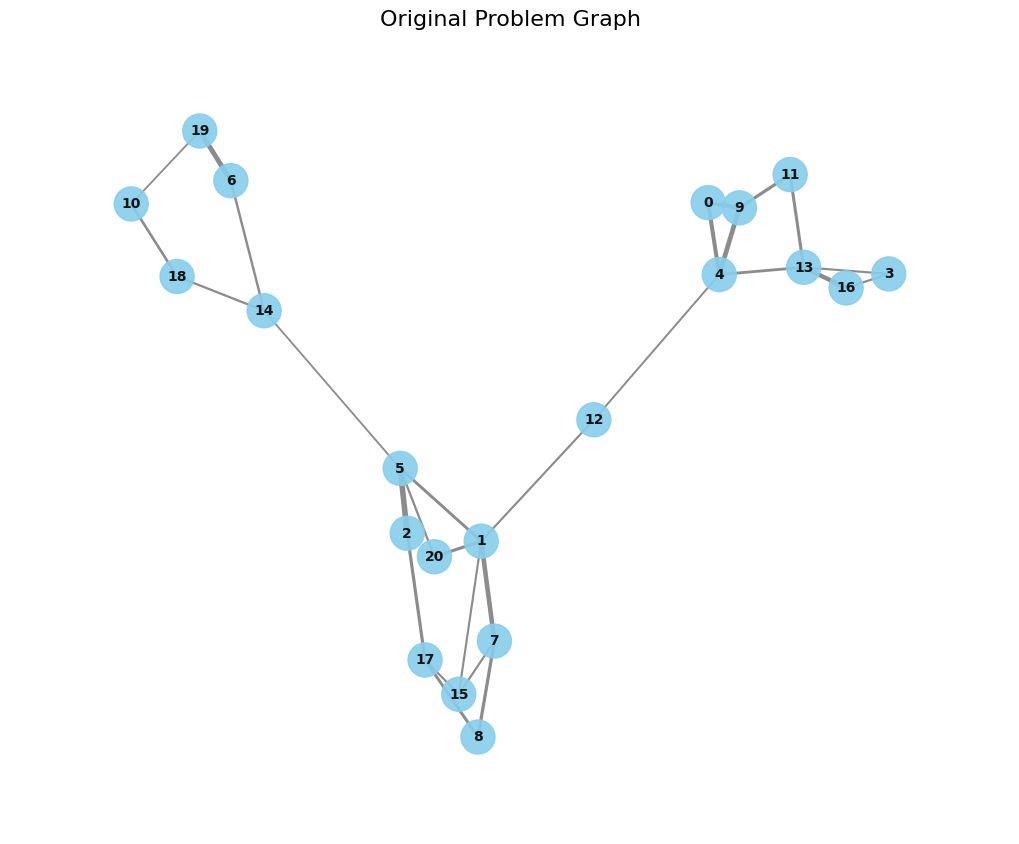

{3: array([1.       , 0.1469551]),
 13: array([0.7762576 , 0.15588401]),
 16: array([0.88788033, 0.12806527]),
 2: array([-0.26519432, -0.20239593]),
 5: array([-0.28365957, -0.11499815]),
 14: array([-0.64128794,  0.09735622]),
 20: array([-0.19377183, -0.23404657]),
 1: array([-0.07082085, -0.21300601]),
 7: array([-0.03614466, -0.34763449]),
 8: array([-0.07935429, -0.47688861]),
 17: array([-0.21837307, -0.37308141]),
 10: array([-0.99043144,  0.24123604]),
 19: array([-0.81030958,  0.33952301]),
 18: array([-0.86984825,  0.14350879]),
 6: array([-0.72861698,  0.27253807]),
 0: array([0.52542647, 0.2430052 ]),
 4: array([0.55453215, 0.14605341]),
 9: array([0.60756154, 0.23597654]),
 12: array([ 0.22513676, -0.04953437]),
 11: array([0.74082339, 0.28079528]),
 15: array([-0.12980546, -0.41931141])}

In [12]:
# Pipeline settings
GRAPH_PATH = Path("../dataset_A.csv")
MAX_SIZE = 8
TOP_T = 10
METHOD = "separator"

# Solver settings
import os
os.environ["QCS_SETTINGS_APPLICATIONS_QVM_URL"] = "http://127.0.0.1:5001"
_solver_module.USE_PYQUIL = True    # Set to False to use stub local search
_solver_module.LAYER_COUNT = 1
_solver_module.SHOTS = 1024
_solver_module.SEED = 42

# Quantum computer target (None = auto-detect QVM)
QC_NAME = "9q-square-qvm"

if _solver_module.USE_PYQUIL and QC_NAME:
    print(f"Setting up QPU: {QC_NAME}...")
    setup_qpu(QC_NAME)

# Load Graph
print(f"\nLoading graph from {GRAPH_PATH}...")
G = load_graph(GRAPH_PATH)
print(f"Loaded graph with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

# Pre-calculate a layout for consistent visualization
global_pos = nx.spring_layout(G, seed=42)
draw_graph(G, "Original Problem Graph", pos=global_pos)


## 3. Graph Partitioning

Partitioning graph (method=separator, max_size=8)...
[partitioner] Splitting: 21 nodes, 28 edges  (method=separator)
[partitioner]  -> |A|=2, |S|=1, |B|=18  (2^|S|=2 separator combos at merge)
[partitioner] Splitting: 19 nodes, 25 edges  (method=separator)
[partitioner]  -> |A|=13, |S|=1, |B|=5  (2^|S|=2 separator combos at merge)
[partitioner] Splitting: 14 nodes, 19 edges  (method=separator)
[partitioner]  -> |A|=6, |S|=1, |B|=7  (2^|S|=2 separator combos at merge)
Created 4 leaf subgraphs.


/var/folders/cn/1yhq64td3_j1p23cdwjs4xsh0000gn/T/ipykernel_13876/4104542379.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(leaves))


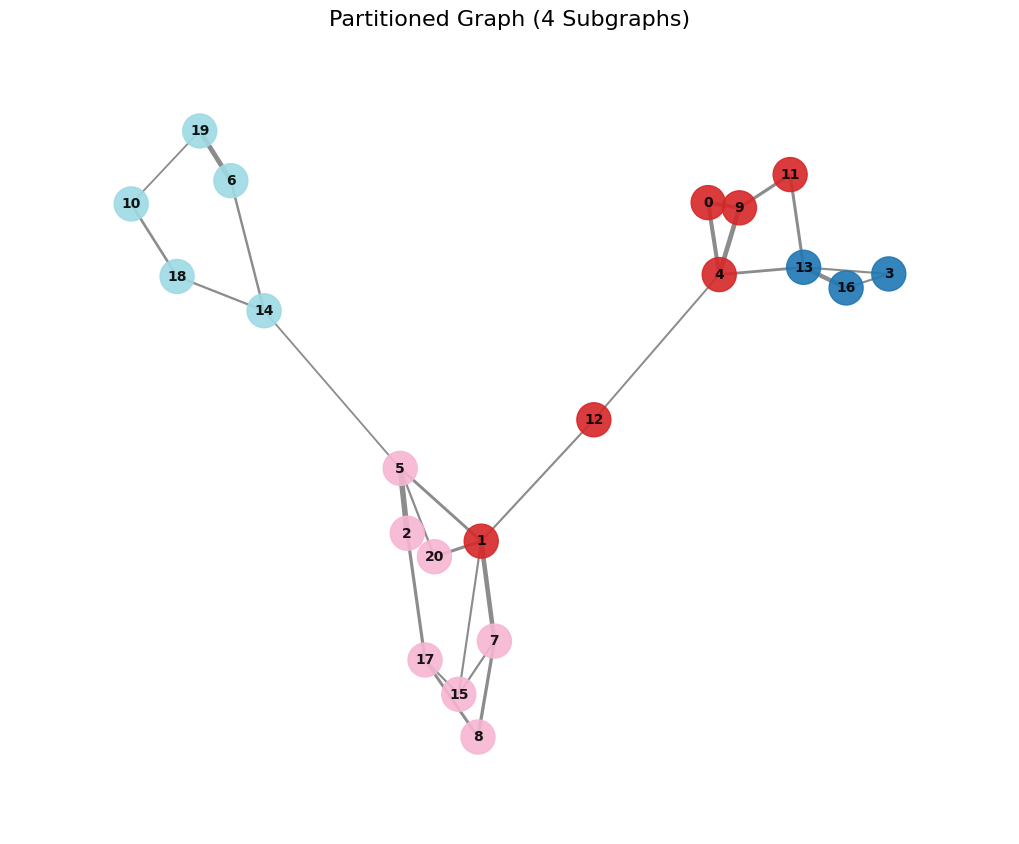

{3: array([1.       , 0.1469551]),
 13: array([0.7762576 , 0.15588401]),
 16: array([0.88788033, 0.12806527]),
 2: array([-0.26519432, -0.20239593]),
 5: array([-0.28365957, -0.11499815]),
 14: array([-0.64128794,  0.09735622]),
 20: array([-0.19377183, -0.23404657]),
 1: array([-0.07082085, -0.21300601]),
 7: array([-0.03614466, -0.34763449]),
 8: array([-0.07935429, -0.47688861]),
 17: array([-0.21837307, -0.37308141]),
 10: array([-0.99043144,  0.24123604]),
 19: array([-0.81030958,  0.33952301]),
 18: array([-0.86984825,  0.14350879]),
 6: array([-0.72861698,  0.27253807]),
 0: array([0.52542647, 0.2430052 ]),
 4: array([0.55453215, 0.14605341]),
 9: array([0.60756154, 0.23597654]),
 12: array([ 0.22513676, -0.04953437]),
 11: array([0.74082339, 0.28079528]),
 15: array([-0.12980546, -0.41931141])}

In [14]:
print(f"Partitioning graph (method={METHOD}, max_size={MAX_SIZE})...")
partition_tree = recursive_partition(G, max_size=MAX_SIZE, method=METHOD)
leaves = partition_tree.leaves()

print(f"Created {len(leaves)} leaf subgraphs.")

# Assign a distinct color index to each leaf subgraph
node_to_leaf_idx = {}
for i, leaf in enumerate(leaves):
    for node in leaf.graph.nodes():
        if node not in node_to_leaf_idx:
            node_to_leaf_idx[node] = i

# Map indices to unique colors
cmap = plt.cm.get_cmap('tab20', len(leaves))
colors = [cmap(node_to_leaf_idx.get(n, 0)) for n in G.nodes()]

draw_graph(G, f"Partitioned Graph ({len(leaves)} Subgraphs)", node_colors=colors, pos=global_pos)

## 4. Solve Leaf Subgraphs with QAOA

In [15]:
subgraph_solutions = {}

for i, leaf in enumerate(leaves):
    n_nodes = leaf.graph.number_of_nodes()
    backend = "pyQuil" if _solver_module.USE_PYQUIL else "stub"
    print(f"\n--- Solving Leaf {i + 1}/{len(leaves)} ---")
    print(f"Nodes: {n_nodes}, Edges: {leaf.graph.number_of_edges()} [{backend}]")
    
    # Solve (QAOA or stub)
    solutions = qaoa_solve(leaf.graph, top_t=TOP_T)
    subgraph_solutions[id(leaf)] = solutions
    
    best = maxcut_score(leaf.graph, solutions[0]) if solutions else 0.0
    print(f"-> Found {len(solutions)} solution(s). Best subgraph cut = {best:.4f}")


--- Solving Leaf 1/4 ---
Nodes: 3, Edges: 3 [pyQuil]
[solver] Gate estimate: 3 qubits, 3 edges, p=1 -> ~27 native 2Q gates (OK)


capi_return is NULL
Call-back cb_calcfc_in__cobyla__user__routines failed.
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.11/site-packages/scipy/optimize/_cobyla_py.py", line 281, in calcfc
Fatal Python error: F2PySwapThreadLocalCallbackPtr: F2PySwapThreadLocalCallbackPtr: PyLong_AsVoidPtr failed
Python runtime state: initialized
    f = sf.fun(x)
        ^^^^^^^^^
  File "/opt/anaconda3/lib/python3.11/site-packages/scipy/optimize/_differentiable_functions.py", line 267, in fun
    self._update_fun()
  File "/opt/anaconda3/lib/python3.11/site-packages/scipy/optimize/_differentiable_functions.py", line 251, in _update_fun
    self._update_fun_impl()
  File "/opt/anaconda3/lib/python3.11/site-packages/scipy/optimize/_differentiable_functions.py", line 155, in update_fun
    self.f = fun_wrapped(self.x)
             ^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.11/site-packages/scipy/optimize/_differentiable_functions.py", line 137, in fun_wrapped
    fx = 

: 

## 5. Merger & GR Policy

In [7]:
print("\nMerging subgraphs via GR policy...")
best_assignment = merge(G, partition_tree, subgraph_solutions, top_t=TOP_T)

# Ensure all nodes have an assignment (fallback to +1)
for n in G.nodes():
    if n not in best_assignment:
        best_assignment[n] = 1

pre_polish_score = maxcut_score(G, best_assignment)
print(f"\nPre-polish Max-Cut Score: {pre_polish_score:.4f}")


Merging subgraphs via GR policy...
[merger] Merged internal node: score=2729.6140, |S|=1, pairs=100, candidates_kept=10
[merger] Merged internal node: score=3380.7952, |S|=1, pairs=100, candidates_kept=10
[merger] Merged internal node: score=3728.4132, |S|=1, pairs=80, candidates_kept=10
[merger] Final score on full graph: 3728.4132

Pre-polish Max-Cut Score: 3728.4132


## 6. Local Search Polish & Final Result

In [8]:
print("Running fast local search pass to polish border assignments...")
best_assignment = _local_search(G, list(G.nodes()), best_assignment)
final_score = maxcut_score(G, best_assignment)

total_weight = sum(d.get("weight", 1.0) for _, _, d in G.edges(data=True))

print(f"\n{'=' * 50}")
print(f"  FINAL RESULTS")
print(f"{'=' * 50}")
print(f"Pre-Polish Score : {pre_polish_score:.4f}")
print(f"Final Score      : {final_score:.4f} (+{final_score - pre_polish_score:.4f})")
print(f"Total Edge Weight: {total_weight:.4f}")
print(f"Approx Ratio     : {final_score / total_weight:.4f}")
print(f"{'=' * 50}")

Running fast local search pass to polish border assignments...

  FINAL RESULTS
Pre-Polish Score : 3728.4132
Final Score      : 3728.4132 (+0.0000)
Total Edge Weight: 4215.6655
Approx Ratio     : 0.8844


## 7. Visualize Final Cut Assignment

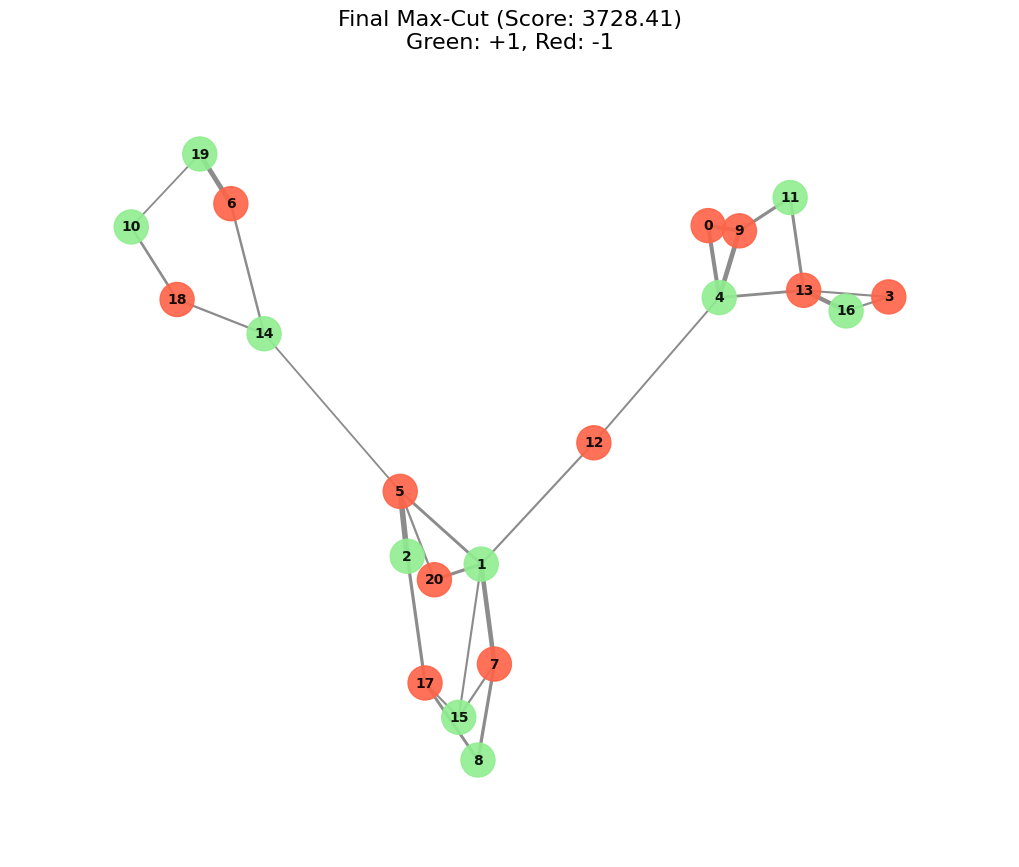

{3: array([1.       , 0.1469551]),
 13: array([0.7762576 , 0.15588401]),
 16: array([0.88788033, 0.12806527]),
 2: array([-0.26519432, -0.20239593]),
 5: array([-0.28365957, -0.11499815]),
 14: array([-0.64128794,  0.09735622]),
 20: array([-0.19377183, -0.23404657]),
 1: array([-0.07082085, -0.21300601]),
 7: array([-0.03614466, -0.34763449]),
 8: array([-0.07935429, -0.47688861]),
 17: array([-0.21837307, -0.37308141]),
 10: array([-0.99043144,  0.24123604]),
 19: array([-0.81030958,  0.33952301]),
 18: array([-0.86984825,  0.14350879]),
 6: array([-0.72861698,  0.27253807]),
 0: array([0.52542647, 0.2430052 ]),
 4: array([0.55453215, 0.14605341]),
 9: array([0.60756154, 0.23597654]),
 12: array([ 0.22513676, -0.04953437]),
 11: array([0.74082339, 0.28079528]),
 15: array([-0.12980546, -0.41931141])}

In [9]:
# +1 spin -> Lightgreen, -1 spin -> Tomato
color_map = {1: 'lightgreen', -1: 'tomato'}
final_colors = [color_map[best_assignment[n]] for n in G.nodes()]

draw_graph(G, f"Final Max-Cut (Score: {final_score:.2f})\nGreen: +1, Red: -1", 
           node_colors=final_colors, pos=global_pos)